# Data Quality Audit of Raw Data from the ENTSO-E Transparency Platform

The main objective of the data quality audit is to assess the quality, consistency, and general characteristics of the raw data obtained from the ENTSO-E Transparency Platform.

The analysis focuses on the following aspects:
* Missing data and missing observations
* Index integrity and consistency
* Duplicated indices
* Timestamp and time zone consistency
* Value ranges and descriptive statistics for each data type
* Overall data characteristics

**All data and variables fetched from ENTSO-E TP are explained in the [ENTSO-E data overview](./01_ENTSOE_data_overview.ipynb).**

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent.parent))
from src.config import (
    DATA_DIR,
    DOWNLOAD_START_DATE,
    DOWNLOAD_END_DATE,
    ENTOSE_BIDDING_ZONE_CODES,
)
from src.eda.validation import (
    print_index_summary,
    print_missing_values,
    print_data_overview,
    find_missing_dates,
)

In [2]:
data_dir = DATA_DIR / "raw" / "entsoe"
date_range = f"{DOWNLOAD_START_DATE}_{DOWNLOAD_END_DATE}"
zone_codes = ENTOSE_BIDDING_ZONE_CODES

## 1. Poland (PL) data

In [3]:
data_dir_pl = data_dir / "PL" / date_range
data_pl = {}
for file in data_dir_pl.iterdir():
    data = pd.read_parquet(file)
    key = file.stem
    data_pl[key] = data

### 1.1 Missing Data

In [4]:
for name, data in data_pl.items():
    print_missing_values(data=data, name=name)


--- [load] Missing values ---
No missing values.

--- [generation] Missing values ---
Other renewable                              13529
Other                                        13529
Hydro Pumped Storage - Actual Consumption    32829
Wind Offshore                                85721

--- [load_forecast] Missing values ---
No missing values.

--- [day_ahead_prices] Missing values ---
No missing values.

--- [generation_wind_solar_forecast] Missing values ---
Wind Offshore    83993

--- [generation_units_unavailability] Missing values ---
docstatus        20045
nominal_power        1

--- [production_units_unavailability] Missing values ---
docstatus    847

--- [generation_forecast] Missing values ---
No missing values.


In [5]:
missing_gen_types = [
    "Other renewable",
    "Other",
    "Hydro Pumped Storage - Actual Consumption",
    "Wind Offshore",
]
data_pl_gen_missing = data_pl["generation"][missing_gen_types]

data_pl_gen_missing["total"] = data_pl["generation"].agg("sum", axis=1)
data_pl_gen_missing

,Other renewable,Other,Hydro Pumped Storage - Actual Consumption,Wind Offshore,total
2022-12-01 00:00:00+01:00,NaN,NaN,NaN,NaN,18124.850
2022-12-01 01:00:00+01:00,NaN,NaN,NaN,NaN,17878.200
2022-12-01 02:00:00+01:00,NaN,NaN,NaN,NaN,17780.410
2022-12-01 03:00:00+01:00,NaN,NaN,NaN,NaN,17754.070
2022-12-01 04:00:00+01:00,NaN,NaN,NaN,NaN,18131.320
...,...,...,...,...,...
2026-09-15 22:45:00+02:00,54.998,552.439,6.737,87.6,17387.193
2026-09-15 23:00:00+02:00,54.492,547.993,8.339,110.4,17564.268
2026-09-15 23:15:00+02:00,54.155,544.366,8.339,134.8,17418.495
2026-09-15 23:30:00+02:00,54.048,544.348,12.090,156.8,17379.289


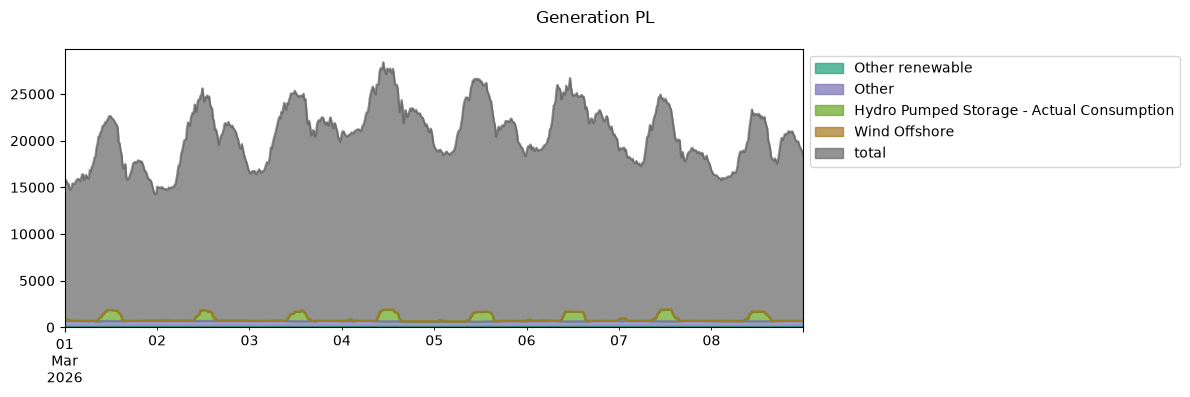

In [6]:
ax = data_pl_gen_missing.loc["2026-03-01":"2026-03-08"].plot(
    kind="area", figsize=(12, 4), cmap="Dark2", alpha=0.7
)

plt.suptitle("Generation PL")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [7]:
print("Contribution to the total generation")
data_pl_gen_missing.apply(lambda x: x / x["total"], axis=1)[missing_gen_types]

Contribution to the total generation


,Other renewable,Other,Hydro Pumped Storage - Actual Consumption,Wind Offshore
2022-12-01 00:00:00+01:00,NaN,NaN,NaN,NaN
2022-12-01 01:00:00+01:00,NaN,NaN,NaN,NaN
2022-12-01 02:00:00+01:00,NaN,NaN,NaN,NaN
2022-12-01 03:00:00+01:00,NaN,NaN,NaN,NaN
2022-12-01 04:00:00+01:00,NaN,NaN,NaN,NaN
...,...,...,...,...
2026-09-15 22:45:00+02:00,0.003163,0.031773,0.000387,0.005038
2026-09-15 23:00:00+02:00,0.003102,0.031199,0.000475,0.006285
2026-09-15 23:15:00+02:00,0.003109,0.031252,0.000479,0.007739
2026-09-15 23:30:00+02:00,0.003110,0.031322,0.000696,0.009022


In [8]:
print(
    f"generation units:\n{data_pl["generation_units_unavailability"]["docstatus"].fillna("N/A").value_counts()}"
)
print(
    f"production units:\n{data_pl["production_units_unavailability"]["docstatus"].fillna("N/A").value_counts()}"
)

generation units:
docstatus
N/A    20045
Name: count, dtype: int64
production units:
docstatus
N/A    847
Name: count, dtype: int64


In [9]:
data_pl["generation_units_unavailability"].head(3)

,avail_qty,biddingzone_domain,businesstype,curvetype,docstatus,end,mrid,nominal_power,plant_type,production_resource_id,production_resource_location,production_resource_name,production_resource_psr_name,pstn,qty_uom,resolution,revision,start
created_doc_time,,,,,,,,,,,,,,,,,,
2025-10-05 16:07:51+02:00,0,PL,Planned maintenance,A03,None,2025-07-31 00:00:00+02:00,od2QLX90wMQXH075xR7Thg,NaN,,19W000000000076Y,,,,1,MAW,PT1M,1,2025-07-01 00:01:00+02:00
2025-10-05 16:13:53+02:00,0,PL,Planned maintenance,A03,None,2025-07-31 23:45:00+02:00,ofw4avnvO1hYlKFB4LHQGw,86.4,Fossil Hard coal,19W000000000213D,Polska,Wrocław,Wrocław Bl3,1,MAW,PT1M,1,2025-06-27 00:01:00+02:00
2025-10-05 16:13:53+02:00,0,PL,Planned maintenance,A03,None,2025-07-31 23:45:00+02:00,ofw4avnvO1hYlKFB4LHQGw,86.4,Fossil Hard coal,19W000000000213D,Polska,Wrocław,Wrocław Bl3,1,MAW,PT1M,1,2025-06-27 00:01:00+02:00


### 1.2 Missing Data – Observations

Most datasets contain no or only a negligible number of missing observations. The main exceptions are **generation**, **wind and solar generation forecasts**, and **generation/production unit unavailability**.

The missing values in the **generation** dataset correspond primarily to production types that are either not relevant to the Polish energy system or make only a marginal contribution to total generation.

In the **wind and solar generation forecasts** dataset, missing values for **Wind Offshore** are mainly related to the fact that the first **Wind Offshore** sources in the Polish market started generating electricity in **July 2026**.

For the **generation/production unit unavailability** datasets, data is fetched using `docstatus="A05"`, which `entsoe-py` passes directly to the ENTSO-E API as `docStatus=A05` (**A05 – Active**). Therefore, all records returned by this filtered query can be treated as active outage reports, even when the parsed `docstatus` field is `None`. The single record with a missing `nominal_power` value will be excluded from further analysis.

### 1.3 Index Integrity

In [10]:
for name, data in data_pl.items():
    print_index_summary(data, name)


--- [load] Index summary ---
Duplicates: 0
Timezone:  Europe/Warsaw

Time steps:
  0 days 00:15:00: 79191
  0 days 01:00:00: 13441

--- [generation] Index summary ---
Duplicates: 0
Timezone:  Europe/Warsaw

Time steps:
  0 days 00:15:00: 79191
  0 days 01:00:00: 13441

--- [load_forecast] Index summary ---
Duplicates: 0
Timezone:  Europe/Warsaw

Time steps:
  0 days 00:15:00: 79191
  0 days 01:00:00: 13441

--- [day_ahead_prices] Index summary ---
Duplicates: 45
Timezone:  Europe/Warsaw

Time steps:
  0 days 00:15:00: 33600
  0 days 01:00:00: 24839
  0 days 00:00:00: 45

--- [generation_wind_solar_forecast] Index summary ---
Duplicates: 0
Timezone:  Europe/Warsaw

Time steps:
  0 days 00:15:00: 79191
  0 days 01:00:00: 13441

--- [generation_units_unavailability] Index summary ---
Duplicates: 7153
Timezone:  Europe/Warsaw

--- [production_units_unavailability] Index summary ---
Duplicates: 292
Timezone:  Europe/Warsaw

--- [generation_forecast] Index summary ---
Duplicates: 0
Timezone

In [11]:
print(
    data_pl["day_ahead_prices"][
        data_pl["day_ahead_prices"].index.duplicated(keep=False)
    ].head(10)
)

n_months = pd.date_range(start=DOWNLOAD_START_DATE, end=DOWNLOAD_END_DATE, freq="ME")
print(f"\nnumber of months in the downloaded data = {len(n_months)}")
print(
    f"number of duplicated index values = {len(data_pl["day_ahead_prices"][data_pl["day_ahead_prices"].index.duplicated()])}"
)

                           day_ahead_prices
2023-01-01 00:00:00+01:00             18.09
2023-01-01 00:00:00+01:00             18.09
2023-02-01 00:00:00+01:00             85.00
2023-02-01 00:00:00+01:00             85.00
2023-03-01 00:00:00+01:00            134.13
2023-03-01 00:00:00+01:00            134.13
2023-04-01 00:00:00+02:00            125.37
2023-04-01 00:00:00+02:00            125.37
2023-05-01 00:00:00+02:00            109.90
2023-05-01 00:00:00+02:00            109.90

number of months in the downloaded data = 45
number of duplicated index values = 45


### 1.4 Index Integrity - observations

Based on the analysis of index values, most datasets contain neither missing observations nor duplicated indices. The majority of datasets use one of two main time steps (**frequency/MTU**): **15 minutes** or **1 hour**. This difference is consistent with the **Market Time Unit (MTU) change introduced in September 2025**, when the MTU changed from 1 hour to 15 minutes.

The **day-ahead prices** dataset is an exception. The analysis identified **45 observations with a 0-minute time step**, all of which correspond to duplicated observations occurring at the first hour of a new month.

Duplicated indices in the **generation/production unit unavailability** dataset result from multiple generation units experiencing outages at the same time. In this case, the duplicates therefore represent multiple valid records rather than erroneous observations.

In [12]:
for name, data in data_pl.items():
    print_data_overview(data, name)


--- [load] Overview ---
Shape: 92633 x 1

Info:
<class 'pandas.DataFrame'>
DatetimeIndex: 92633 entries, 2022-12-01 00:00:00+01:00 to 2026-09-15 23:45:00+02:00
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Actual Load  92633 non-null  float64
dtypes: float64(1)
memory usage: 1.4 MB

Description:
        Actual Load
count  92633.000000
mean   18305.505318
std     3152.694048
min    10463.962000
25%    15753.941000
50%    18411.141000
75%    20451.363000
max    28303.880000

--- [generation] Overview ---
Shape: 92633 x 15

Info:
<class 'pandas.DataFrame'>
DatetimeIndex: 92633 entries, 2022-12-01 00:00:00+01:00 to 2026-09-15 23:45:00+02:00
Data columns (total 15 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Biomass                                    92633 non-null  float64
 1   Fossil Brown coal/Lignite

### 1.5 Visual Analysis for selected data

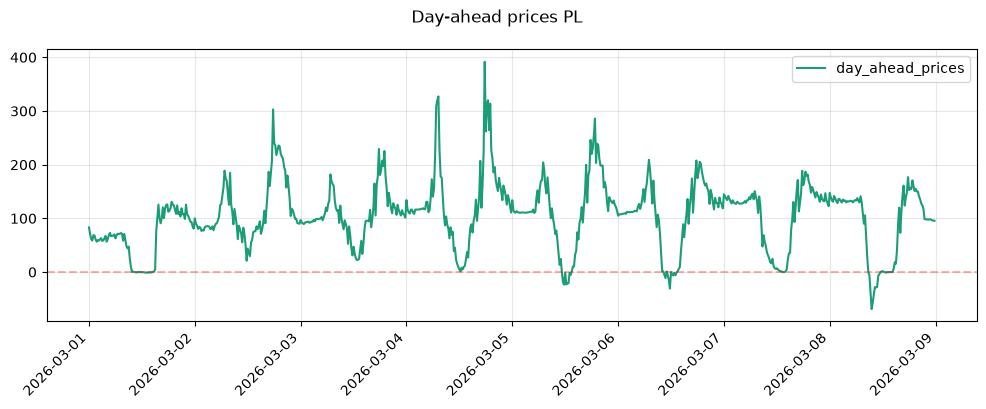

In [13]:
data_pl["day_ahead_prices"].loc["2026-03-01":"2026-03-08"].plot(
    figsize=(12, 4), cmap="Dark2"
)
plt.suptitle("Day-ahead prices PL")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.axhline(y=0, c="r", linestyle="--", alpha=0.3)
plt.show()

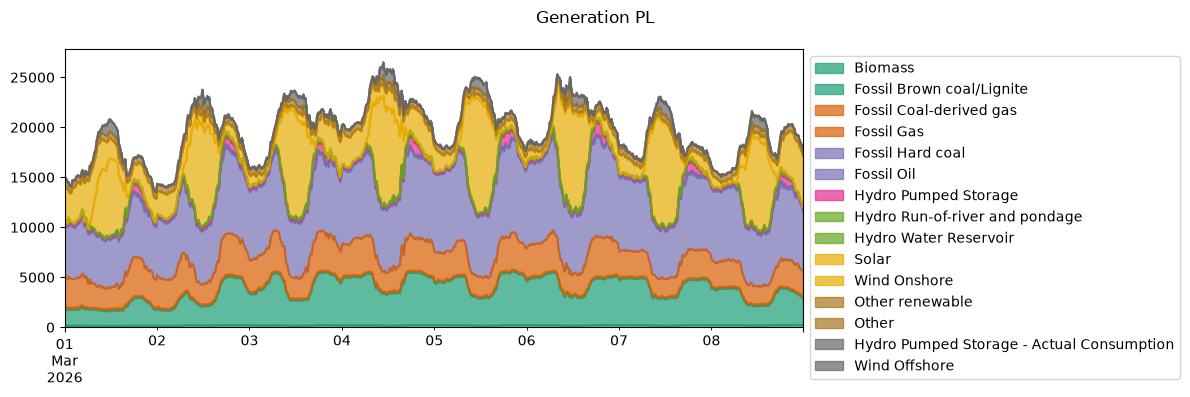

In [14]:
data_pl_generation = data_pl["generation"]
ax = data_pl_generation.loc["2026-03-01":"2026-03-08"].plot(
    kind="area", figsize=(12, 4), cmap="Dark2", alpha=0.7
)

plt.suptitle("Generation PL")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

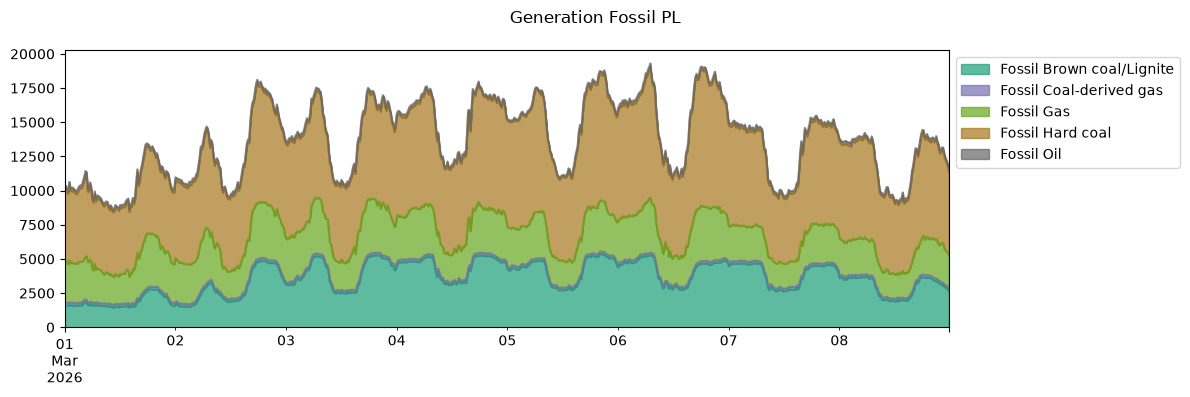

In [15]:
data_pl_generation_fossil = data_pl["generation"][
    [c for c in data_pl["generation"].columns if "Fossil" in c]
]
ax = data_pl_generation_fossil.loc["2026-03-01":"2026-03-08"].plot(
    kind="area", figsize=(12, 4), cmap="Dark2", alpha=0.7
)

plt.suptitle("Generation Fossil PL")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

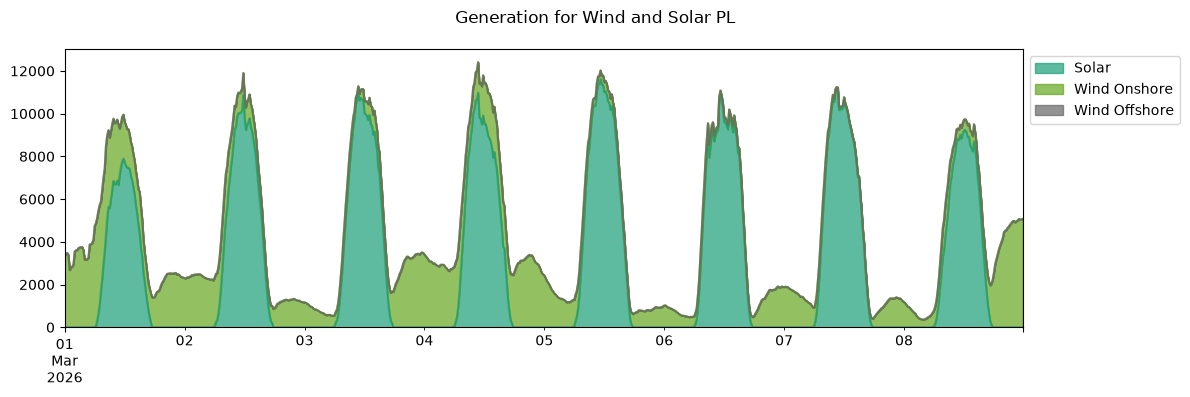

In [16]:
data_pl_generation_wind_solar = data_pl["generation"][
    [c for c in data_pl["generation"].columns if "Solar" in c or "Wind" in c]
]
ax = data_pl_generation_wind_solar.loc["2026-03-01":"2026-03-08"].plot(
    kind="area", figsize=(12, 4), alpha=0.7, cmap="Dark2"
)

plt.suptitle("Generation for Wind and Solar PL")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

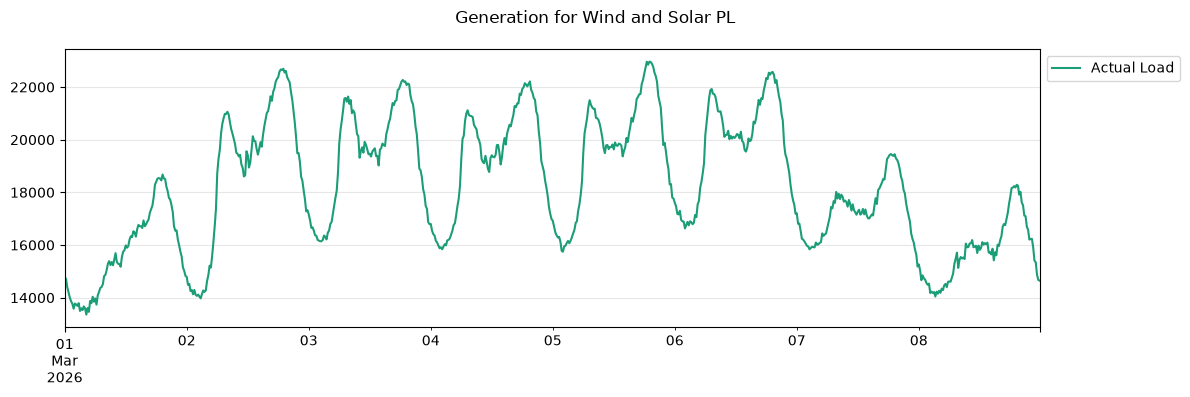

In [17]:
ax = (
    data_pl["load"]
    .loc["2026-03-01":"2026-03-08"]
    .plot(kind="line", figsize=(12, 4), cmap="Dark2")
)
plt.suptitle("Generation for Wind and Solar PL")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Other Eurpean Bidding Zones included data

In [18]:
data_entose = {
    bz: {
        file.stem: pd.read_parquet(file)
        for file in (data_dir / bz / date_range).iterdir()
    }
    for bz in ENTOSE_BIDDING_ZONE_CODES
}

### 2.1 Missing Data

In [19]:
for bz, data_bz in [(bz, data) for bz, data in data_entose.items() if bz != "PL"]:
    print(f"\n--- {bz} " + "-" * 40)

    for key, data in data_bz.items():
        print_missing_values(data=data, name=key)


--- AT ----------------------------------------

--- [load_forecast] Missing values ---
No missing values.

--- [water_reservoirs_hydro_storage] Missing values ---
No missing values.

--- [day_ahead_prices] Missing values ---
No missing values.

--- [generation_wind_solar_forecast] Missing values ---
No missing values.

--- [generation_forecast] Missing values ---
No missing values.

--- CZ ----------------------------------------

--- [load_forecast] Missing values ---
No missing values.

--- [day_ahead_prices] Missing values ---
No missing values.

--- [generation_wind_solar_forecast] Missing values ---
No missing values.

--- [generation_forecast] Missing values ---
No missing values.

--- DE_LU ----------------------------------------

--- [load_forecast] Missing values ---
No missing values.

--- [day_ahead_prices] Missing values ---
No missing values.

--- [generation_wind_solar_forecast] Missing values ---
Solar           12
Wind Onshore    12

--- [generation_units_unavailabil

In [20]:
print("[DE_LU] - missing values for generation_wind_solar_forecast\n")

missing_wind_onshore_de_lu = data_entose["DE_LU"]["generation_wind_solar_forecast"][
    "Wind Onshore"
][data_entose["DE_LU"]["generation_wind_solar_forecast"]["Wind Onshore"].isna()]
print("\nWind Onshore")
print(f"total missing: {len(missing_wind_onshore_de_lu)}\n")
print(missing_wind_onshore_de_lu.index)

missing_solar_de_lu = data_entose["DE_LU"]["generation_wind_solar_forecast"]["Solar"][
    data_entose["DE_LU"]["generation_wind_solar_forecast"]["Solar"].isna()
]
print("\nSolar")
print(f"total missing: {len(missing_solar_de_lu)}\n")
print(missing_solar_de_lu.index)

[DE_LU] - missing values for generation_wind_solar_forecast


Wind Onshore
total missing: 12

DatetimeIndex(['2023-10-29 00:00:00+02:00', '2023-10-29 00:15:00+02:00',
               '2023-10-29 00:30:00+02:00', '2023-10-29 00:45:00+02:00',
               '2024-10-27 00:00:00+02:00', '2024-10-27 00:15:00+02:00',
               '2024-10-27 00:30:00+02:00', '2024-10-27 00:45:00+02:00',
               '2025-10-26 00:00:00+02:00', '2025-10-26 00:15:00+02:00',
               '2025-10-26 00:30:00+02:00', '2025-10-26 00:45:00+02:00'],
              dtype='datetime64[us, Europe/Berlin]', freq=None)

Solar
total missing: 12

DatetimeIndex(['2023-10-29 00:00:00+02:00', '2023-10-29 00:15:00+02:00',
               '2023-10-29 00:30:00+02:00', '2023-10-29 00:45:00+02:00',
               '2024-10-27 00:00:00+02:00', '2024-10-27 00:15:00+02:00',
               '2024-10-27 00:30:00+02:00', '2024-10-27 00:45:00+02:00',
               '2025-10-26 00:00:00+02:00', '2025-10-26 00:15:00+02:00',
            

In [21]:
print("[FR] - missing values for generation_wind_solar_forecast\n")

missing_wind_onshore_fr = data_entose["FR"]["generation_wind_solar_forecast"][
    "Wind Onshore"
][data_entose["FR"]["generation_wind_solar_forecast"]["Wind Onshore"].isna()]
print("\nWind Onshore")
print(f"total missing: {len(missing_wind_onshore_fr)}\n")
print(missing_wind_onshore_fr.index)

missing_wind_offshore_fr = data_entose["FR"]["generation_wind_solar_forecast"][
    "Wind Offshore"
][data_entose["FR"]["generation_wind_solar_forecast"]["Wind Offshore"].isna()]
print("\nWind Offshore")
print(f"total missing: {len(missing_wind_offshore_fr)}\n")
print(missing_wind_offshore_fr.index)

missing_solar_fr = data_entose["FR"]["generation_wind_solar_forecast"]["Solar"][
    data_entose["FR"]["generation_wind_solar_forecast"]["Solar"].isna()
]
print("\nSolar")
print(f"total missing: {len(missing_solar_fr)}\n")
print(missing_solar_fr.index)

[FR] - missing values for generation_wind_solar_forecast


Wind Onshore
total missing: 27

DatetimeIndex(['2023-10-29 23:00:00+01:00', '2024-10-27 23:00:00+01:00',
               '2025-10-26 23:00:00+01:00', '2026-01-02 00:00:00+01:00',
               '2026-01-02 01:00:00+01:00', '2026-01-02 02:00:00+01:00',
               '2026-01-02 03:00:00+01:00', '2026-01-02 04:00:00+01:00',
               '2026-01-02 05:00:00+01:00', '2026-01-02 06:00:00+01:00',
               '2026-01-02 07:00:00+01:00', '2026-01-02 08:00:00+01:00',
               '2026-01-02 09:00:00+01:00', '2026-01-02 10:00:00+01:00',
               '2026-01-02 11:00:00+01:00', '2026-01-02 12:00:00+01:00',
               '2026-01-02 13:00:00+01:00', '2026-01-02 14:00:00+01:00',
               '2026-01-02 15:00:00+01:00', '2026-01-02 16:00:00+01:00',
               '2026-01-02 17:00:00+01:00', '2026-01-02 18:00:00+01:00',
               '2026-01-02 19:00:00+01:00', '2026-01-02 20:00:00+01:00',
               '2026-01-02 21:00:

In [22]:
print("[HU] - missing values generation_wind_solar_forecast")
missing_wind_onshore_hu = data_entose["HU"]["generation_wind_solar_forecast"][
    "Wind Onshore"
][data_entose["HU"]["generation_wind_solar_forecast"]["Wind Onshore"].isna()]
print("\nWind Onshore")
print(f"total missing: {len(missing_wind_onshore_hu)}\n")
print(missing_wind_onshore_hu.index)

[HU] - missing values generation_wind_solar_forecast

Wind Onshore
total missing: 34

DatetimeIndex(['2026-02-16 15:30:00+01:00', '2026-02-16 15:45:00+01:00',
               '2026-02-16 16:00:00+01:00', '2026-02-16 16:15:00+01:00',
               '2026-02-16 16:30:00+01:00', '2026-02-16 16:45:00+01:00',
               '2026-02-16 17:00:00+01:00', '2026-02-16 17:15:00+01:00',
               '2026-02-16 17:30:00+01:00', '2026-02-16 17:45:00+01:00',
               '2026-02-16 18:00:00+01:00', '2026-02-16 18:15:00+01:00',
               '2026-02-16 18:30:00+01:00', '2026-02-16 18:45:00+01:00',
               '2026-02-16 19:00:00+01:00', '2026-02-16 19:15:00+01:00',
               '2026-02-16 19:30:00+01:00', '2026-02-16 19:45:00+01:00',
               '2026-02-16 20:00:00+01:00', '2026-02-16 20:15:00+01:00',
               '2026-02-16 20:30:00+01:00', '2026-02-16 20:45:00+01:00',
               '2026-02-16 21:00:00+01:00', '2026-02-16 21:15:00+01:00',
               '2026-02-16 21:30:00+01

In [23]:
print("[LT] - missing values for generation")
generation_forecast_lt = data_entose["LT"]["generation_forecast"]
generation_forecast_lt["Actual Aggregated"].info()
print(f"\ntotal values: {len(generation_forecast_lt)}")
generation_forecast_lt["Actual Aggregated"]

[LT] - missing values for generation
<class 'pandas.Series'>
DatetimeIndex: 83049 entries, 2022-12-01 01:00:00+02:00 to 2026-09-16 00:45:00+03:00
Series name: Actual Aggregated
Non-Null Count  Dtype  
--------------  -----  
8640 non-null   float64
dtypes: float64(1)
memory usage: 1.3 MB

total values: 83049


2022-12-01 01:00:00+02:00   NaN
2022-12-01 02:00:00+02:00   NaN
2022-12-01 03:00:00+02:00   NaN
2022-12-01 04:00:00+02:00   NaN
2022-12-01 05:00:00+02:00   NaN
                             ..
2026-09-15 23:45:00+03:00   NaN
2026-09-16 00:00:00+03:00   NaN
2026-09-16 00:15:00+03:00   NaN
2026-09-16 00:30:00+03:00   NaN
2026-09-16 00:45:00+03:00   NaN
Name: Actual Aggregated, Length: 83049, dtype: float64

### 2.2 Missing Data - observations

The characteristics of missing values in the other bidding zones are largely consistent with those observed in the Polish datasets. Most datasets contain no missing observations, with the main exceptions being **generation/production unit unavailability** and **wind and solar generation forecasts**.

For **generation/production unit unavailability**, the **DE_LU** and **FR** datasets exhibit the same `docstatus` issue as the Polish datasets. Data is fetched using `docstatus="A05"`, which `entsoe-py` passes directly to the ENTSO-E API as `docStatus=A05` (**A05 – Active**). Therefore, records returned by this filtered query can be treated as active outage reports, even when the parsed `docstatus` field is `None`.

For **wind and solar generation forecasts**, missing values for **Wind Onshore** and **Solar** mainly correspond to short periods for which no forecasts are available. The larger number of missing values for **Wind Offshore** is primarily related to the absence of forecasts during the corresponding periods.

The **Lithuanian generation forecast** dataset differs from the other datasets in both data granularity and naming conventions. In combination with the relatively large amount of missing data, these differences make the dataset unsuitable for inclusion in the final dataset.

### 2.3 Index integrity

In [24]:
for bz, data_bz in [(bz, data) for bz, data in data_entose.items() if bz != "PL"]:
    print(f"\n--- {bz} " + "-" * 40)

    for key, data in data_bz.items():
        print_index_summary(data=data, name=key)


--- AT ----------------------------------------

--- [load_forecast] Index summary ---
Duplicates: 0
Timezone:  Europe/Vienna

Time steps:
  0 days 00:15:00: 132955

--- [water_reservoirs_hydro_storage] Index summary ---
Duplicates: 0
Timezone:  UTC

Time steps:
  7 days 00:00:00: 194
  14 days 00:00:00: 1

--- [day_ahead_prices] Index summary ---
Duplicates: 0
Timezone:  Europe/Vienna

Time steps:
  0 days 00:15:00: 33598
  0 days 01:00:00: 24835
  0 days 02:00:00: 2
  0 days 00:30:00: 1

--- [generation_wind_solar_forecast] Index summary ---
Duplicates: 0
Timezone:  Europe/Vienna

Time steps:
  0 days 00:15:00: 132955

--- [generation_forecast] Index summary ---
Duplicates: 0
Timezone:  Europe/Vienna

Time steps:
  0 days 00:15:00: 28795
  0 days 01:00:00: 26040

--- CZ ----------------------------------------

--- [load_forecast] Index summary ---
Duplicates: 0
Timezone:  Europe/Prague

Time steps:
  0 days 00:15:00: 77559
  0 days 01:00:00: 13849

--- [day_ahead_prices] Index summ

In [25]:
for bz, data_bz in [(bz, data) for bz, data in data_entose.items() if bz != "PL"]:
    print(f"\n--- {bz} " + "-" * 40)

    for key, data in data_bz.items():
        find_missing_dates(data=data, name=key)


--- AT ----------------------------------------

--- [load_forecast] Missing dates ---
Count: 0

--- [day_ahead_prices] Missing dates ---
Count: 3

Missing ranges:
  2023-11-30 00:00:00+01:00
  2024-11-30 00:00:00+01:00
  2025-11-30 00:00:00+01:00

Missing by day of week:
  Thursday: 1
  Saturday: 1
  Sunday: 1

--- [generation_wind_solar_forecast] Missing dates ---
Count: 0

--- [generation_forecast] Missing dates ---
Count: 0

--- CZ ----------------------------------------

--- [load_forecast] Missing dates ---
Count: 0

--- [day_ahead_prices] Missing dates ---
Count: 3

Missing ranges:
  2023-11-30 00:00:00+01:00
  2024-11-30 00:00:00+01:00
  2025-11-30 00:00:00+01:00

Missing by day of week:
  Thursday: 1
  Saturday: 1
  Sunday: 1

--- [generation_wind_solar_forecast] Missing dates ---
Count: 0

--- [generation_forecast] Missing dates ---
Count: 0

--- DE_LU ----------------------------------------

--- [load_forecast] Missing dates ---
Count: 2

Missing ranges:
  2023-10-29 00:0

### 2.4 Index Integrity - observations

Based on the analysis of index values, most datasets contain no duplicated indices. The majority of datasets use one of two main time steps (**frequency/MTU**): **15 minutes** or **1 hour**. This is consistent with the **Market Time Unit (MTU) change introduced in September 2025**, when the MTU changed from 1 hour to 15 minutes.

The **day-ahead prices** datasets contain a small number of irregular time steps. In addition to the standard 15-minute and 1-hour intervals, two observations have a **2-hour** time step and one observation has a **30-minute** time step. These are isolated observations and do not indicate a systematic change in dataset frequency.

A small number of irregular time steps are also present in the **load forecast**, **wind and solar generation forecast**, and **generation forecast** datasets. These irregularities are generally isolated observations. The **Lithuanian generation forecast** dataset is an exception, as it contains several substantially larger gaps, with time steps ranging from **1 day to more than 8 days**.

The **water reservoirs hydro storage** datasets use a **weekly** time step, with one **14-day** interval observed in the data. This pattern is consistent across the countries for which this dataset is available.

Duplicated indices occur only in the **generation/production unit unavailability** datasets for **DE_LU** and **FR**. As in the Polish datasets, these duplicates result from multiple generation units experiencing outages at the same time.

## 3. Conclusions and Data Preprocessing Decisions

### 3.1 Poland (PL) Datasets

**3.1.1** Due to the amount of missing data and their marginal contribution to total generation, the following production types from the *generation* dataset will not be used in further analysis: *Other Renewable* (13,529), *Other* (13,529), *Hydro Pumped Storage – Actual Consumption* (32,829), and *Wind Offshore* (85,721). The same approach will be applied to *Wind Offshore* in the *generation_wind_solar_forecast* dataset.

**3.1.2** Missing `docstatus` values in the *production_units_unavailability* and *generation_units_unavailability* datasets will be treated as *Active*. Records with missing `nominal_power` values will be excluded. The remaining data will be aggregated into unavailable quantity by plant type and reindexed to match the applicable MTU.

**3.1.3** No significant gaps were identified in the indices. The **45 duplicated observations** occurring at the first hour of a new month will be deduplicated by keeping the first observation. Missing index observations will be filled using **linear interpolation** to ensure a continuous time series for further analysis.

### 3.2 Other European Bidding Zones

**3.2.1** For **France (FR)**, as in the Polish dataset, *Wind Offshore* from the *generation_wind_solar_forecast* dataset will not be used in further analysis. Missing values for *Wind Onshore* and *Solar* covering the entire day of **2026-01-02** will be filled using values from the previous day (**D-1**). Other individual gaps will be filled using **linear interpolation**.

**3.2.2** Missing values for *Wind Onshore* generation in the *generation_wind_solar_forecast* dataset for **Hungary (HU)**, covering the period from **15:30 to 23:45 on 2026-02-16**, will be filled using values from the previous day (**D-1**).

**3.2.3** The *generation_forecast* dataset for **Lithuania (LT)** will not be used in further analysis due to the significant amount of missing data and differences in data granularity and naming conventions.

**3.2.4** Missing `docstatus` values in the *production_units_unavailability* and *generation_units_unavailability* datasets, missing `nominal_power` values, and the subsequent data transformation for **Germany (DE_LU)** and **France (FR)** will be handled in the same way as for the Polish datasets.

**3.2.5** Most identified gaps in the indices are no longer than **2–3 MTUs** and will therefore be filled using **linear interpolation** to ensure continuous time series and prevent issues during further analysis.